Phase 1: data warmup
      0 | data: 1.00e+00
   5000 | data: 9.65e-04
  10000 | data: 2.72e-05
  15000 | data: 3.81e-08
Phase 2: data + physics
      0 | data: 5.12e-09 | phys: 7.93e-01 | total: 7.93e-02
   5000 | data: 3.77e-05 | phys: 3.92e-02 | total: 3.95e-03
  10000 | data: 9.08e-06 | phys: 2.16e-02 | total: 2.17e-03
  15000 | data: 7.77e-07 | phys: 2.67e-03 | total: 2.67e-04
Phase 3: L-BFGS
Done.
Model saved.


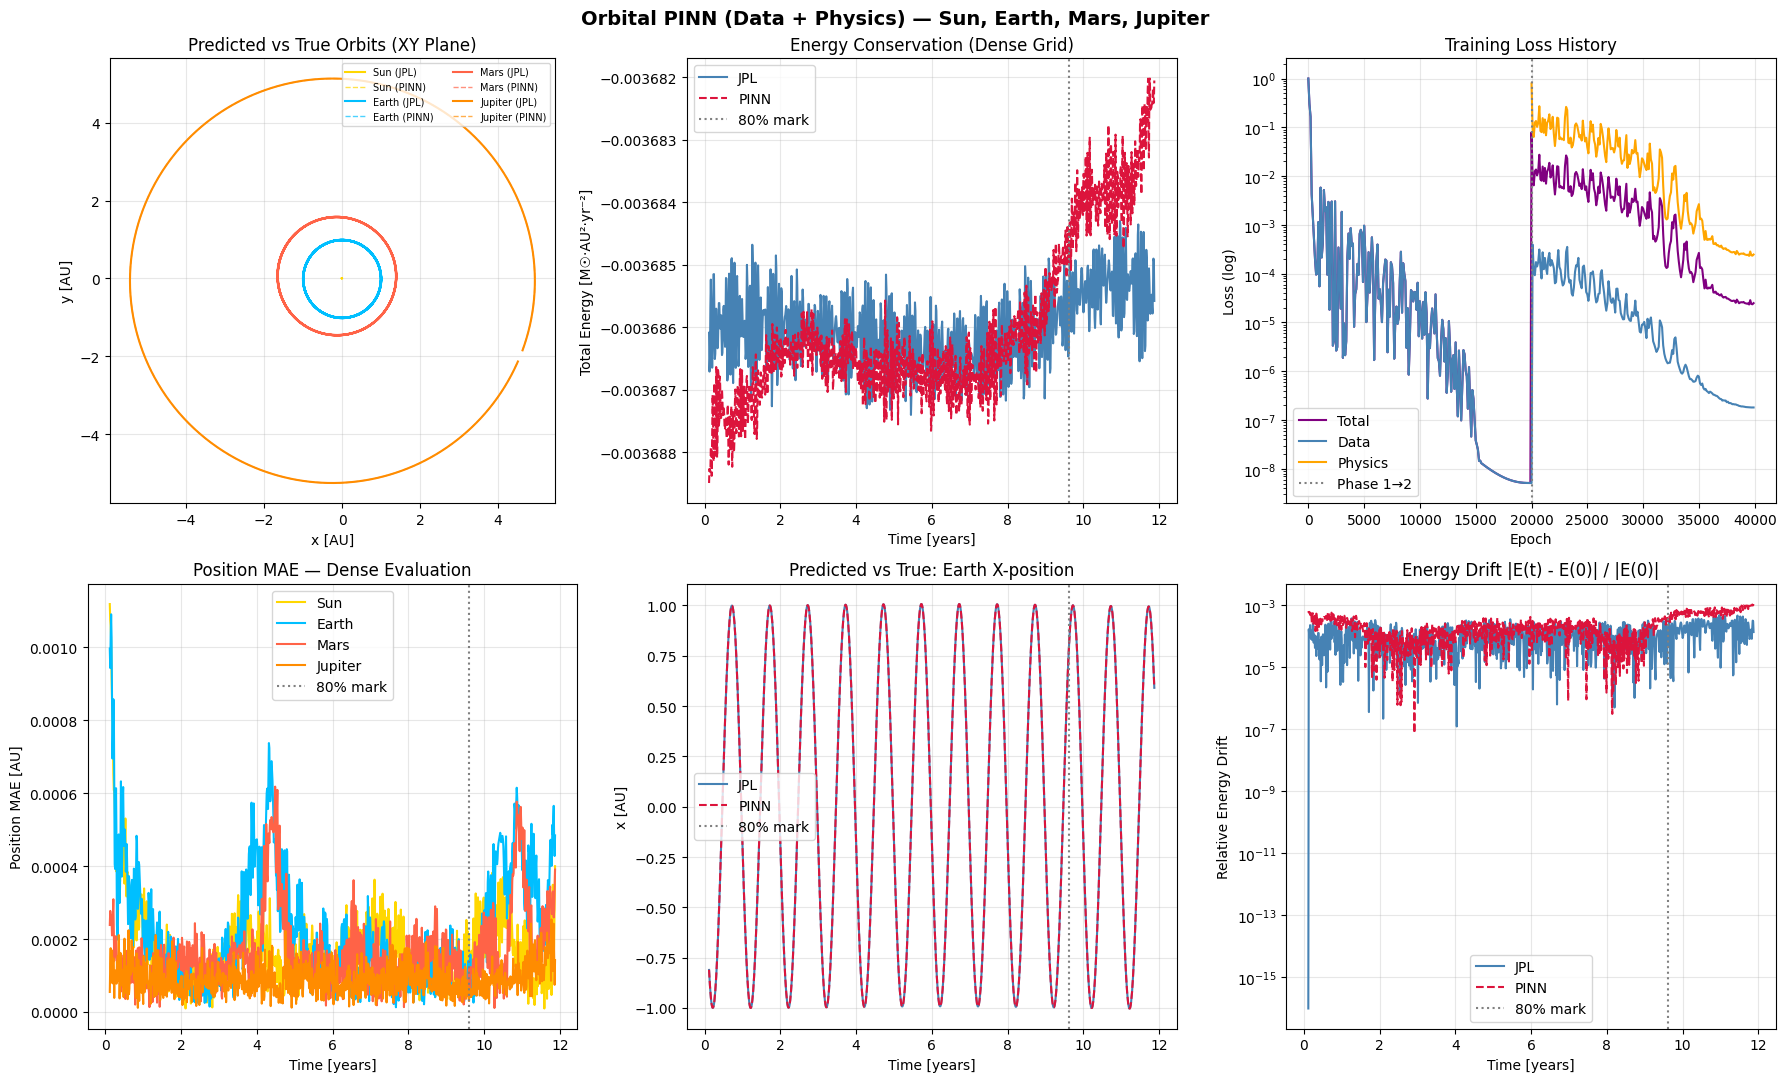


===== Final Metrics =====
Sun      | Train MAE: 0.000196 AU | Test MAE: 0.000198 AU
Earth    | Train MAE: 0.000240 AU | Test MAE: 0.000245 AU
Mars     | Train MAE: 0.000168 AU | Test MAE: 0.000159 AU
Jupiter  | Train MAE: 0.000089 AU | Test MAE: 0.000102 AU

Mean Energy Drift (PINN): 0.000269
Mean Energy Drift (JPL):  0.000130


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
import pandas as pd
from scipy.interpolate import interp1d

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BODIES = {
    "Sun":     {"id": 10,  "mass": 1.0},
    "Earth":   {"id": 399, "mass": 3.003e-6},
    "Mars":    {"id": 499, "mass": 3.227e-7},
    "Jupiter": {"id": 599, "mass": 9.548e-4},
}
BODY_NAMES = list(BODIES.keys())
N_BODIES   = len(BODIES)
START, STOP, STEP = "2010-01-01", "2022-01-01", "10d"
G_AU = 4 * np.pi**2

def fetch_ephemeris():
    dfs = []
    for name, info in BODIES.items():
        obj = Horizons(id=info["id"], location="500@0",
                       epochs={"start": START, "stop": STOP, "step": STEP})
        vec = obj.vectors()
        df  = vec["datetime_jd", "x", "y", "z", "vx", "vy", "vz"].to_pandas()
        df.columns = ["jd", "x", "y", "z", "vx", "vy", "vz"]
        df["body"] = name
        dfs.append(df)
    return pd.concat(dfs).sort_values("jd")

raw     = fetch_ephemeris()
jd_vals = raw[raw["body"] == "Sun"]["jd"].values
t_years = (jd_vals - jd_vals[0]) / 365.25
T       = len(t_years)

states = np.zeros((T, N_BODIES, 6))
for i, name in enumerate(BODY_NAMES):
    sub = raw[raw["body"] == name].sort_values("jd")
    states[:, i, 0] = sub["x"].values
    states[:, i, 1] = sub["y"].values
    states[:, i, 2] = sub["z"].values
    states[:, i, 3] = sub["vx"].values * 365.25
    states[:, i, 4] = sub["vy"].values * 365.25
    states[:, i, 5] = sub["vz"].values * 365.25

t_norm   = (t_years - t_years.min()) / (t_years.max() - t_years.min())
pos_std  = float(states[:, :, :3].std())
vel_std  = float(states[:, :, 3:].std())
t_scale  = float(t_years.max() - t_years.min())

states_norm = states.copy()
states_norm[:, :, :3] /= pos_std
states_norm[:, :, 3:] /= vel_std

t_tensor      = torch.tensor(t_norm, dtype=torch.float32).unsqueeze(1).to(DEVICE)
states_tensor = torch.tensor(states_norm.reshape(T, -1), dtype=torch.float32).to(DEVICE)

rng       = np.random.default_rng(42)
n_blocks  = T // 5
test_idx  = np.array([rng.integers(b*5, b*5+5) for b in range(n_blocks)])
train_idx = np.setdiff1d(np.arange(T), test_idx)
N_SPLIT   = int(0.8 * T)

t_train = t_tensor[train_idx];  s_train = states_tensor[train_idx]
t_test  = t_tensor[test_idx];   s_test  = states_tensor[test_idx]
masses_np = np.array([BODIES[b]["mass"] for b in BODY_NAMES])
MASSES    = torch.tensor(masses_np, dtype=torch.float32).to(DEVICE)

class OrbitalPINN(nn.Module):
    def __init__(self, n_bodies=4, hidden=512, n_layers=8, fourier_dim=64):
        super().__init__()
        periods    = torch.tensor([11.86, 1.0, 1.88, 11.86], dtype=torch.float32)
        base_freqs = (2 * np.pi / periods).unsqueeze(1)
        harmonics  = torch.arange(1, fourier_dim // len(periods) + 1, dtype=torch.float32).unsqueeze(0)
        seeded     = (base_freqs * harmonics).flatten()[:fourier_dim]
        random_pad = torch.randn(max(0, fourier_dim - len(seeded))) * 5
        self.B = nn.Parameter(torch.cat([seeded, random_pad])[:fourier_dim].unsqueeze(0), requires_grad=False)
        layers = [nn.Linear(fourier_dim * 2, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, n_bodies * 6)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        proj = t * self.B * 2 * np.pi
        return self.net(torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1))

def physics_loss(model, t_col, masses, G, pos_std, vel_std, t_scale):
    t_col = t_col.clone().detach().requires_grad_(True)
    out   = model(t_col)
    dout  = torch.zeros_like(out)
    for k in range(out.shape[1]):
        dout[:, k] = torch.autograd.grad(
            out[:, k].sum(), t_col,
            create_graph=True, retain_graph=True
        )[0].squeeze()

    out_r  = out.reshape(-1, N_BODIES, 6)
    dout_r = dout.reshape(-1, N_BODIES, 6)

    pos_phys  = out_r[:, :, :3] * pos_std
    vel_phys  = out_r[:, :, 3:] * vel_std
    dpos_phys = dout_r[:, :, :3] * pos_std / t_scale
    dvel_phys = dout_r[:, :, 3:] * vel_std / t_scale

    accel = torch.zeros_like(pos_phys)
    for i in range(N_BODIES):
        for j in range(N_BODIES):
            if i == j: continue
            r_ij  = pos_phys[:, j, :] - pos_phys[:, i, :]
            dist3 = (r_ij.norm(dim=-1, keepdim=True) + 1e-8) ** 3
            accel[:, i, :] += G * masses[j] * r_ij / dist3

    return (( dout_r[:, :, :3] * pos_std / t_scale - vel_phys) ** 2).mean() + \
           ((dvel_phys - accel) ** 2).mean()

model = OrbitalPINN(n_bodies=N_BODIES).to(DEVICE)

# ── Phase 1: data warmup ─────────────────────────────────────────────────────
PHASE1 = 20000
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, total_steps=PHASE1, pct_start=0.1, anneal_strategy="cos")

loss_hist = {"data": [], "physics": [], "total": []}

print("Phase 1: data warmup")
for epoch in range(PHASE1):
    model.train(); optimizer.zero_grad()
    loss = nn.MSELoss()(model(t_train), s_train)
    loss.backward(); optimizer.step(); scheduler.step()
    if epoch % 100 == 0:
        loss_hist["data"].append(loss.item())
        loss_hist["physics"].append(np.nan)
        loss_hist["total"].append(loss.item())
    if epoch % 5000 == 0:
        print(f"  {epoch:5d} | data: {loss:.2e}")

# ── Phase 2: data + physics ──────────────────────────────────────────────────
PHASE2    = 20000
N_COLLOC  = 300
LAMBDA    = 0.1

optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2)

print("Phase 2: data + physics")
for epoch in range(PHASE2):
    model.train(); optimizer2.zero_grad()
    t_col  = torch.rand(N_COLLOC, 1, dtype=torch.float32).to(DEVICE)
    l_data = nn.MSELoss()(model(t_train), s_train)
    l_phys = physics_loss(model, t_col, MASSES, G_AU, pos_std, vel_std, t_scale)
    loss   = l_data + LAMBDA * l_phys
    loss.backward(); optimizer2.step(); scheduler2.step()
    if epoch % 100 == 0:
        loss_hist["data"].append(l_data.item())
        loss_hist["physics"].append(l_phys.item())
        loss_hist["total"].append(loss.item())
    if epoch % 5000 == 0:
        print(f"  {epoch:5d} | data: {l_data:.2e} | phys: {l_phys:.2e} | total: {loss:.2e}")

# ── Phase 3: L-BFGS polish ───────────────────────────────────────────────────
print("Phase 3: L-BFGS")
opt_lb = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=1000,
                             history_size=100, line_search_fn="strong_wolfe")
def closure():
    opt_lb.zero_grad()
    t_col  = torch.rand(N_COLLOC, 1, dtype=torch.float32).to(DEVICE)
    l_data = nn.MSELoss()(model(t_train), s_train)
    l_phys = physics_loss(model, t_col, MASSES, G_AU, pos_std, vel_std, t_scale)
    loss   = l_data + LAMBDA * l_phys
    loss.backward(); return loss
opt_lb.step(closure)
print("Done.")

torch.save({
    "model_state": model.state_dict(),
    "pos_std": pos_std, "vel_std": vel_std, "t_scale": t_scale,
    "t_years_min": t_years.min(), "t_years_max": t_years.max(),
    "body_names": BODY_NAMES, "masses": masses_np.tolist(),
}, "orbital_pinn.pt")
print("Model saved.")

# ── Evaluation ───────────────────────────────────────────────────────────────
model.eval()
t_dense_np = np.linspace(0.01, 0.99, 1000)
t_dense    = torch.tensor(t_dense_np, dtype=torch.float32).unsqueeze(1).to(DEVICE)
t_dense_yr = t_dense_np * t_scale + t_years.min()

with torch.no_grad():
    pred_dense     = model(t_dense).cpu().numpy().reshape(-1, N_BODIES, 6)
    pred_train_pts = model(t_train).cpu().numpy().reshape(-1, N_BODIES, 6)
    pred_test_pts  = model(t_test).cpu().numpy().reshape(-1, N_BODIES, 6)

pred_dense[:, :, :3] *= pos_std;  pred_dense[:, :, 3:] *= vel_std

true_dense = np.zeros_like(pred_dense)
for i in range(N_BODIES):
    for d in range(6):
        scale = pos_std if d < 3 else vel_std
        f = interp1d(t_norm, states_norm[:, i, d] * scale, kind="cubic")
        true_dense[:, i, d] = f(t_dense_np)

true_train_pts = states_tensor[train_idx].cpu().numpy().reshape(-1, N_BODIES, 6)
true_test_pts  = states_tensor[test_idx].cpu().numpy().reshape(-1, N_BODIES, 6)
for arr in [true_train_pts, true_test_pts, pred_train_pts, pred_test_pts]:
    arr[:, :, :3] *= pos_std;  arr[:, :, 3:] *= vel_std

def compute_energy(s, m):
    E = np.zeros(len(s))
    for t in range(len(s)):
        KE = 0.5 * sum(m[i] * np.sum(s[t, i, 3:]**2) for i in range(N_BODIES))
        PE = sum(-G_AU * m[i] * m[j] /
                 (np.linalg.norm(s[t, j, :3] - s[t, i, :3]) + 1e-12)
                 for i in range(N_BODIES) for j in range(i+1, N_BODIES))
        E[t] = KE + PE
    return E

E_true     = compute_energy(true_dense, masses_np)
E_pred     = compute_energy(pred_dense, masses_np)
drift_true = np.abs(E_true - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
drift_pred = np.abs(E_pred - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
COLORS     = ["gold", "deepskyblue", "tomato", "darkorange"]

total_epochs  = PHASE1 + PHASE2
epoch_axis    = np.arange(0, total_epochs, 100)
phase_split_e = PHASE1 // 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Orbital PINN (Data + Physics) — Sun, Earth, Mars, Jupiter", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.set_title("Predicted vs True Orbits (XY Plane)")
for i, name in enumerate(BODY_NAMES):
    ax.plot(true_dense[:, i, 0], true_dense[:, i, 1], color=COLORS[i], lw=1.5, label=f"{name} (JPL)")
    ax.plot(pred_dense[:, i, 0], pred_dense[:, i, 1], color=COLORS[i], lw=1, ls="--", alpha=0.7, label=f"{name} (PINN)")
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.legend(fontsize=7, ncol=2); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.set_title("Energy Conservation (Dense Grid)")
ax.plot(t_dense_yr, E_true, label="JPL",  color="steelblue")
ax.plot(t_dense_yr, E_pred, label="PINN", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="80% mark")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Total Energy [M☉·AU²·yr⁻²]")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.set_title("Training Loss History")
data_arr  = np.array(loss_hist["data"],    dtype=float)
total_arr = np.array(loss_hist["total"],   dtype=float)
phys_arr  = np.array(loss_hist["physics"], dtype=float)
ax.semilogy(epoch_axis, total_arr, color="purple",    label="Total")
ax.semilogy(epoch_axis, data_arr,  color="steelblue", label="Data")
phys_mask = ~np.isnan(phys_arr)
ax.semilogy(epoch_axis[phys_mask], phys_arr[phys_mask], color="orange", label="Physics")
ax.axvline(PHASE1, color="gray", ls=":", label="Phase 1→2")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log)"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.set_title("Position MAE — Dense Evaluation")
mae = np.abs(pred_dense[:, :, :3] - true_dense[:, :, :3]).mean(axis=2)
for i, name in enumerate(BODY_NAMES):
    ax.plot(t_dense_yr, mae[:, i], color=COLORS[i], label=name)
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="80% mark")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Position MAE [AU]")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.set_title("Predicted vs True: Earth X-position")
ax.plot(t_dense_yr, true_dense[:, 1, 0], label="JPL",  color="steelblue")
ax.plot(t_dense_yr, pred_dense[:, 1, 0], label="PINN", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="80% mark")
ax.set_xlabel("Time [years]"); ax.set_ylabel("x [AU]"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.set_title("Energy Drift |E(t) - E(0)| / |E(0)|")
ax.semilogy(t_dense_yr, drift_true + 1e-16, label="JPL",  color="steelblue")
ax.semilogy(t_dense_yr, drift_pred + 1e-16, label="PINN", color="crimson", ls="--")
ax.axvline(t_years[N_SPLIT], color="gray", ls=":", label="80% mark")
ax.set_xlabel("Time [years]"); ax.set_ylabel("Relative Energy Drift")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("orbital_pinn_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n===== Final Metrics =====")
for i, name in enumerate(BODY_NAMES):
    mae_tr = np.abs(pred_train_pts[:, i, :3] - true_train_pts[:, i, :3]).mean()
    mae_te = np.abs(pred_test_pts[:, i, :3]  - true_test_pts[:, i, :3]).mean()
    print(f"{name:8s} | Train MAE: {mae_tr:.6f} AU | Test MAE: {mae_te:.6f} AU")
print(f"\nMean Energy Drift (PINN): {drift_pred.mean():.6f}")
print(f"Mean Energy Drift (JPL):  {drift_true.mean():.6f}")